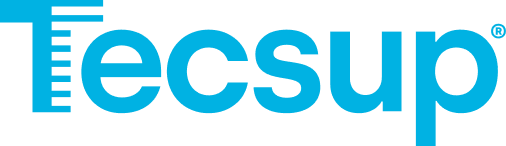

# DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN
## Carrera de Big Data y Ciencia de Datos
# LABORATORIO 14: CONCEPTOS PRELIMINARES. MULTICLASIFICADORES

## Integrante:
- Kevin Estiben Olortegui Perez

- **Configuración del entorno:**

In [1]:
#  %pip install pandas numpy polars ucimlrepo scikit-learn pytest pyarrow


## 1. VARIABLES GLOBALES

In [2]:
# Nombre de la variable objetivo
TARGET_COLUMN = 'actual_productivity'

# Proporción para el conjunto de prueba
TEST_SIZE = 0.2

# Semilla para garantizar reproducibilidad
RANDOM_STATE = 42

In [3]:
import logging
from typing import List, Tuple
import pandas as pd
import numpy as np
import polars as pl
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, BaggingRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 2. FUNCIONES (../src/utils.py)

In [4]:
%%writefile utils.py
import logging
from typing import List, Tuple
import pandas as pd
import numpy as np
import polars as pl
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, BaggingRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def load_and_prepare_data() -> pd.DataFrame:
    """
    Carga y prepara el dataset eliminando la columna 'date'.
    Returns:
        DataFrame listo para preprocesamiento.
    """
    data = fetch_ucirepo(id=597)
    df = pd.concat([data.data.features, data.data.targets], axis=1)
    df = pl.from_pandas(df).drop("date").to_pandas()
    return df

def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Imputa valores nulos usando la mediana.
    Versión mejorada que evita el FutureWarning de pandas.
    """
    df_copy = df.copy()  # Trabajamos con una copia explícita
    
    for col in df_copy.columns:
        if df_copy[col].isnull().sum() > 0:
            # Método recomendado que evita el warning
            df_copy[col] = df_copy[col].fillna(df_copy[col].median())
    
    logging.info(f"Valores faltantes imputados en {df_copy.columns[df.isnull().any()].tolist()}")
    return df_copy

def treat_outliers_iqr(df: pd.DataFrame, num_cols: List[str]) -> pd.DataFrame:
    """
    Aplica capping para outliers usando IQR.
    Versión mejorada con logging.
    """
    df_copy = df.copy()
    outliers_info = {}
    
    for col in num_cols:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Contar outliers antes del tratamiento
        outliers_count = ((df_copy[col] < lower) | (df_copy[col] > upper)).sum()
        outliers_info[col] = outliers_count
        
        df_copy[col] = np.clip(df_copy[col], lower, upper)
    
    logging.info(f"Outliers tratados: {outliers_info}")
    return df_copy

def convert_to_dummies(df: pd.DataFrame, cat_cols: List[str]) -> pd.DataFrame:
    """
    Convierte variables categóricas a dummies.
    Versión mejorada con validación.
    """
    if not cat_cols:
        logging.info("No hay variables categóricas para convertir")
        return df
    
    df_dummies = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=float)
    logging.info(f"Variables categóricas convertidas: {cat_cols}")
    logging.info(f"Nuevas columnas dummy: {[col for col in df_dummies.columns if col not in df.columns]}")
    
    return df_dummies

def train_and_evaluate_models(X_train: pd.DataFrame, y_train: pd.Series,
                               X_test: pd.DataFrame, y_test: pd.Series,
                               random_state: int) -> pd.DataFrame:
    """
    Entrena y evalúa modelos ensamblados.
    Versión mejorada con mejor manejo de errores y logging.
    """
    # Modelos base con hiperparámetros mejorados
    r1 = LinearRegression()
    r2 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=random_state)
    r3 = KNeighborsRegressor(n_neighbors=5)
    r4 = SVR(kernel='rbf', C=10.0, gamma='scale')
    r5 = DecisionTreeRegressor(max_depth=8, random_state=random_state)

    models = {
        'Voting': VotingRegressor([('lr', r1), ('rf', r2), ('knn', r3)]),
        'Bagging': BaggingRegressor(r5, n_estimators=100, random_state=random_state),
        'Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=random_state),
        'Stacking': StackingRegressor([('rf', r2), ('knn', r3), ('svr', r4)], final_estimator=r1)
    }

    results = []
    for name, model in models.items():
        try:
            logging.info(f"Entrenando modelo: {name}")
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            mse = mean_squared_error(y_test, pred)
            
            results.append({
                "Modelo": name,
                "MSE": mse,
                "RMSE": np.sqrt(mse),
                "MAE": mean_absolute_error(y_test, pred),
                "R2 Score": r2_score(y_test, pred)
            })
            logging.info(f"Modelo {name} entrenado exitosamente")
            
        except Exception as e:
            logging.error(f"Error entrenando modelo {name}: {str(e)}")
            continue
    
    return pd.DataFrame(results)

def analyze_data_quality(df: pd.DataFrame) -> dict:
    """
    Función adicional para análisis de calidad de datos.
    """
    quality_report = {
        'shape': df.shape,
        'missing_values': df.isnull().sum().to_dict(),
        'duplicates': df.duplicated().sum(),
        'dtypes': df.dtypes.to_dict()
    }
    
    # Estadísticas para variables numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        quality_report['numeric_stats'] = df[numeric_cols].describe().to_dict()
    
    return quality_report

Overwriting utils.py


## 3. IMPLEMENTACIÓN PRINCIPAL

### 3.1 Parte A: Preprocesamiento

In [5]:
import utils

In [6]:
# - Carga de datos
# - Tratamiento de nulos y outliers
# - Conversión a dummies
# - Identificación de columnas numéricas

df = utils.load_and_prepare_data()
df = utils.handle_missing_values(df)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
df = utils.convert_to_dummies(df, cat_cols)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove(TARGET_COLUMN)
df = utils.treat_outliers_iqr(df, num_cols)

2025-06-24 18:38:30,275 - INFO - Valores faltantes imputados en ['wip']
2025-06-24 18:38:30,278 - INFO - Variables categóricas convertidas: ['quarter', 'department', 'day']
2025-06-24 18:38:30,279 - INFO - Nuevas columnas dummy: ['quarter_Quarter2', 'quarter_Quarter3', 'quarter_Quarter4', 'quarter_Quarter5', 'department_sweing', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']
2025-06-24 18:38:30,304 - INFO - Outliers tratados: {'team': np.int64(0), 'targeted_productivity': np.int64(79), 'smv': np.int64(0), 'wip': np.int64(358), 'over_time': np.int64(1), 'incentive': np.int64(11), 'idle_time': np.int64(18), 'idle_men': np.int64(18), 'no_of_style_change': np.int64(147), 'no_of_workers': np.int64(0), 'quarter_Quarter2': np.int64(0), 'quarter_Quarter3': np.int64(210), 'quarter_Quarter4': np.int64(248), 'quarter_Quarter5': np.int64(44), 'department_sweing': np.int64(0), 'day_Saturday': np.int64(187), 'day_Sunday': np.int64(203), 'day_Thursday': np.int64(199), '

### 3.2 Parte B: División y escalado

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
X = df.drop(columns=TARGET_COLUMN)
y = df[TARGET_COLUMN]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

### 3.3 Parte C: Entrenamiento y evaluación

In [9]:
results = utils.train_and_evaluate_models(X_train, y_train, X_test, y_test, RANDOM_STATE)
print("\n--- Resultados de Modelos ---")
print(results.sort_values(by="R2 Score", ascending=False))

2025-06-24 18:38:30,337 - INFO - Entrenando modelo: Voting
2025-06-24 18:38:31,921 - INFO - Modelo Voting entrenado exitosamente
2025-06-24 18:38:31,922 - INFO - Entrenando modelo: Bagging
2025-06-24 18:38:32,160 - INFO - Modelo Bagging entrenado exitosamente
2025-06-24 18:38:32,161 - INFO - Entrenando modelo: Boosting
2025-06-24 18:38:32,376 - INFO - Modelo Boosting entrenado exitosamente
2025-06-24 18:38:32,377 - INFO - Entrenando modelo: Stacking
2025-06-24 18:38:33,863 - INFO - Modelo Stacking entrenado exitosamente



--- Resultados de Modelos ---
     Modelo       MSE      RMSE       MAE  R2 Score
1   Bagging  0.012517  0.111881  0.073404  0.528579
3  Stacking  0.012947  0.113783  0.074915  0.512417
0    Voting  0.013174  0.114777  0.075665  0.503864
2  Boosting  0.014881  0.121988  0.079515  0.439558


## 4. TESTING (test_utils.py)

In [10]:
%%writefile test_utils.py
import pytest
import pandas as pd
import numpy as np
import utils

@pytest.fixture
def df_sample():
    return pd.DataFrame({
        'num1': [1, 2, 3, 4, 100],
        'num2': [10, 20, np.nan, 40, 50],
        'cat': ['A', 'B', 'A', 'C', 'B'],
        'actual_productivity': [1.1, 2.2, 3.3, 4.4, 5.5]
    })

def test_handle_missing(df_sample):
    df = utils.handle_missing_values(df_sample.copy())
    assert df['num2'].isnull().sum() == 0

def test_outlier_treatment(df_sample):
    df = utils.treat_outliers_iqr(df_sample.copy(), ['num1'])
    assert df['num1'].max() <= df_sample['num1'].quantile(0.75) + 1.5 * (df_sample['num1'].quantile(0.75) - df_sample['num1'].quantile(0.25))

def test_dummies(df_sample):
    df = utils.convert_to_dummies(df_sample.copy(), ['cat'])
    assert 'cat_B' in df.columns
    assert 'cat_C' in df.columns
    assert 'cat' not in df.columns

Overwriting test_utils.py


## 5. EJECUCIÓN

In [11]:
!pytest test_utils.py -v --disable-warnings

============================= test session starts =============================
platform win32 -- Python 3.13.5, pytest-8.4.1, pluggy-1.6.0 -- d:\V Ciclo\MD\Semana 14\olortegui_lab14\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: d:\V Ciclo\MD\Semana 14\olortegui_lab14\lab14
collecting ... collected 3 items

test_utils.py::test_handle_missing PASSED                                [ 33%]
test_utils.py::test_outlier_treatment PASSED                             [ 66%]
test_utils.py::test_dummies PASSED                                       [100%]

============================== 3 passed in 1.55s ==============================
